## Bước 0: Thống kê & gỡ trùng (trước tiền xử lý văn bản)

Dữ liệu từ `01_Data_Collection.ipynb` có thể **trùng `tmdb_id`** (do danh sách *popular* thay đổi giữa các trang) và **trùng review** khi cùng một phim bị lặp.

Cell dưới đây:

1. In **thống kê** (quy mô, phủ review, độ dài text, số trùng).
2. **Gỡ trùng**: movies giữ bản ghi đầu tiên theo `tmdb_id`; reviews theo cặp `(review_id, tmdb_id)`; bỏ review thuộc phim không còn trong bảng phim.
3. **Lọc phim “câm”**: xoá các phim **vừa không có review trong CSV vừa `overview` rỗng** (sau strip) — không còn tín hiệu text cho downstream.
4. **Ghi đè** lại `cinesense_movies.csv` và `cinesense_reviews.csv` để mọi bước sau + `seed_sqlite_from_csv.py` dùng bản sạch.

Sau khi notebook 02 chạy xong và bạn hài lòng:

```bash
# Từ thư mục gốc repo — xoá DB cũ rồi nạp lại
rm -f data/cinesense.db
python scripts/seed_sqlite_from_csv.py
```



In [1]:
import pandas as pd

MOVIES_CSV = "cinesense_movies.csv"
REVIEWS_CSV = "cinesense_reviews.csv"

dfm = pd.read_csv(MOVIES_CSV)
dfr = pd.read_csv(REVIEWS_CSV)

print("=" * 62)
print("THỐNG KÊ RAW (trước gỡ trùng)")
print("=" * 62)
print(f"Số dòng movies: {len(dfm):,}  |  reviews: {len(dfr):,}")

# Chuẩn hoá tmdb_id
dfm["tmdb_id"] = pd.to_numeric(dfm["tmdb_id"], errors="coerce")
dfr["tmdb_id"] = pd.to_numeric(dfr["tmdb_id"], errors="coerce")
bad_m = dfm["tmdb_id"].isna().sum()
bad_r = dfr["tmdb_id"].isna().sum()
if bad_m or bad_r:
    print(f"CẢNH BÁO: tmdb_id không phân tích được — movies {bad_m}, reviews {bad_r}")

n_m = dfm["tmdb_id"].duplicated().sum()
print(f"Dòng movies trùng tmdb_id: {int(n_m)}  (unique: {dfm['tmdb_id'].nunique():,})")

print(
    f"Dòng reviews trùng (review_id,tmdb_id): {int(dfr.duplicated(subset=['review_id', 'tmdb_id']).sum())}"
)

movie_set = set(dfm["tmdb_id"].dropna().astype(int))
rev_set = set(dfr["tmdb_id"].dropna().astype(int))
orphan = rev_set - movie_set
print(f"Review thuộc tmdb_id không có trong movies: {len(orphan)}")

ov = dfm["overview"].fillna("").astype(str)
ge = dfm["genres"].fillna("").astype(str)
print(f"Movies: overview rỗng {int((ov.str.len() == 0).sum())}  |  genres rỗng {int((ge.str.len() == 0).sum())}")

ct = dfr["content"].fillna("").astype(str)
print(f"Reviews: content rỗng {int((ct.str.len() == 0).sum())}")
print(
    "Độ dài content (ký tự): min=%s  median=%.0f  p95=%.0f  max=%s"
    % (int(ct.str.len().min()), ct.str.len().median(), ct.str.len().quantile(0.95), int(ct.str.len().max()))
)

vc = dfr.groupby("tmdb_id").size()
print(f"Phim có ≥1 review (raw): {len(vc):,}")

print("\n" + "=" * 62)
print("GỠ TRÙNG & GHI FILE")
print("=" * 62)

dfm_clean = dfm.drop_duplicates(subset=["tmdb_id"], keep="first").copy()
dfr_clean = dfr.drop_duplicates(subset=["review_id", "tmdb_id"], keep="first")
dfr_clean = dfr_clean[dfr_clean["tmdb_id"].isin(dfm_clean["tmdb_id"])]
# bỏ cột phụ

print(f"Sau dedupe — movies: {len(dfm_clean):,}  reviews: {len(dfr_clean):,}")
vc2 = dfr_clean.groupby("tmdb_id").size()
print(
    "Phim có review: %s  |  không có review: %s"
    % (len(vc2), len(dfm_clean) - len(vc2))
)
print(
    "Reviews/phim: min=%s  median=%.2f  max=%s  mean=%.2f"
    % (int(vc2.min()), vc2.median(), int(vc2.max()), vc2.mean())
)

# Loại phim vừa không có review trong CSV vừa overview rỗng (không có tín hiệu text)
tids_with_rev = set(dfr_clean["tmdb_id"].dropna().astype(int))
ov_nonempty = (
    dfm_clean["overview"].fillna("").astype(str).str.strip().str.len() > 0
)
has_rev = dfm_clean["tmdb_id"].astype(int).isin(tids_with_rev)
keep_mask = ov_nonempty | has_rev
n_drop_both = int((~keep_mask).sum())
print(
    f"\nLoại phim (0 review + overview rỗng): {n_drop_both} — còn lại {keep_mask.sum():,} phim"
)
dfm_clean = dfm_clean[keep_mask].copy()
dfr_clean = dfr_clean[dfr_clean["tmdb_id"].isin(dfm_clean["tmdb_id"])]
vc3 = dfr_clean.groupby("tmdb_id").size()
print(
    "Sau lọc — movies: %s  reviews: %s | phim có review: %s"
    % (len(dfm_clean), len(dfr_clean), len(vc3))
)

dfm_clean.to_csv(MOVIES_CSV, index=False, encoding="utf-8")
dfr_clean.to_csv(REVIEWS_CSV, index=False, encoding="utf-8")
print("\nĐã ghi đè:", MOVIES_CSV, ",", REVIEWS_CSV)



THỐNG KÊ RAW (trước gỡ trùng)
Số dòng movies: 4,815  |  reviews: 12,029
Dòng movies trùng tmdb_id: 0  (unique: 4,815)
Dòng reviews trùng (review_id,tmdb_id): 0
Review thuộc tmdb_id không có trong movies: 0
Movies: overview rỗng 18  |  genres rỗng 35
Reviews: content rỗng 0
Độ dài content (ký tự): min=20  median=999  p95=3708  max=23498
Phim có ≥1 review (raw): 3,230

GỠ TRÙNG & GHI FILE
Sau dedupe — movies: 4,815  reviews: 12,029
Phim có review: 3230  |  không có review: 1585
Reviews/phim: min=1  median=3.00  max=20  mean=3.72

Loại phim (0 review + overview rỗng): 18 — còn lại 4,797 phim
Sau lọc — movies: 4797  reviews: 12029 | phim có review: 3230

Đã ghi đè: cinesense_movies.csv , cinesense_reviews.csv


# Giai đoạn 2: Tiền Xử Lý Dữ Liệu & EDA

Sau **Bước 0** (thống kê & gỡ trùng) ở trên, các cell tiếp theo: đọc 2 bảng quan hệ, làm sạch text, join → `movie_profile` / `review_profile`.



1. Làm sạch Overview và Review Content...
   -> Đã lưu absa_clean_reviews.csv (12027 dòng)
2. Gộp reviews theo từng bộ phim (Group by tmdb_id)...
3. Left Join Movies với Reviews_Grouped...

Đã tạo xong profiles! Ví dụ Phim 1:
movie_profile: title: Your Heart Will Be Broken | overview: high school student polina is saved from bullying at her new school and makes a deal with the main bully bars he must pretend to be her boyfriend and protect her and she must do everything he says during this game the couple develops real feelings but her family and classmates have reasons to separate the lovers | genres: Drama, Romance | reviews:  ...
review_profile:  ...

--- Bắt đầu EDA ---


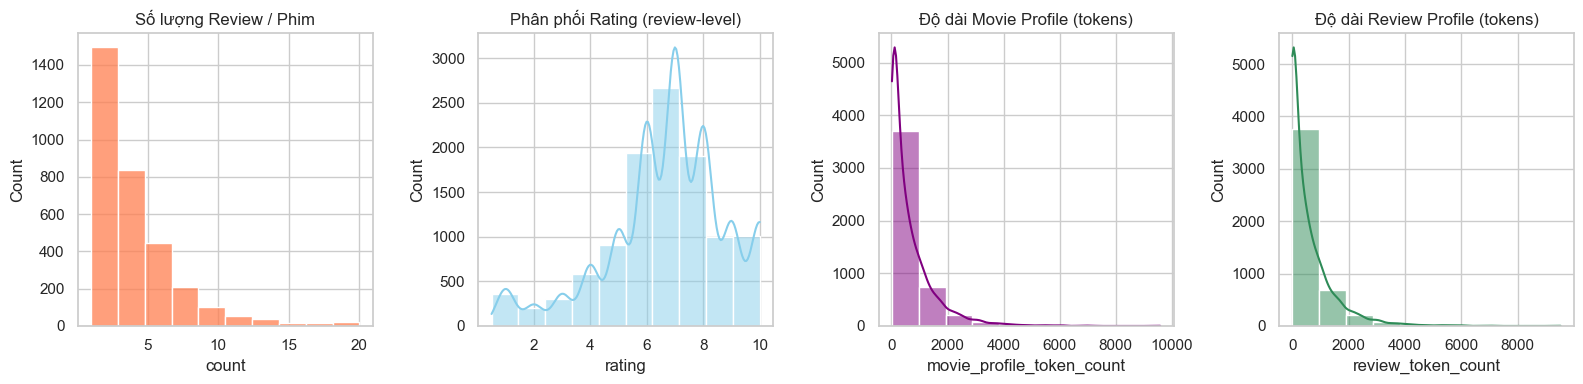


--- EDA bổ sung: Genres frequency / Word frequency / Rating / Sentence length ---


/var/folders/v_/617pz6cj0fgdk8cbm7kv5s9r0000gn/T/ipykernel_80672/2050357551.py:197: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette="viridis")


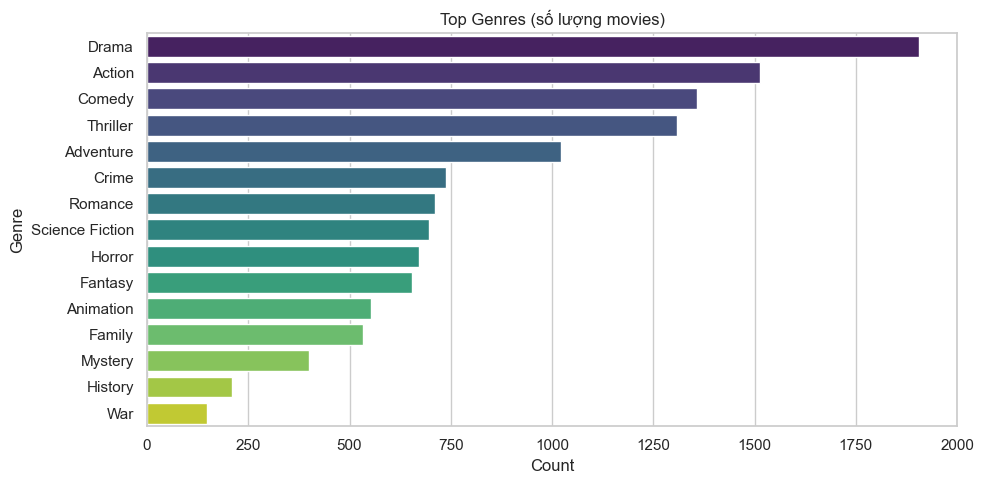

/var/folders/v_/617pz6cj0fgdk8cbm7kv5s9r0000gn/T/ipykernel_80672/2050357551.py:221: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_counts, y=top_words, palette="mako")


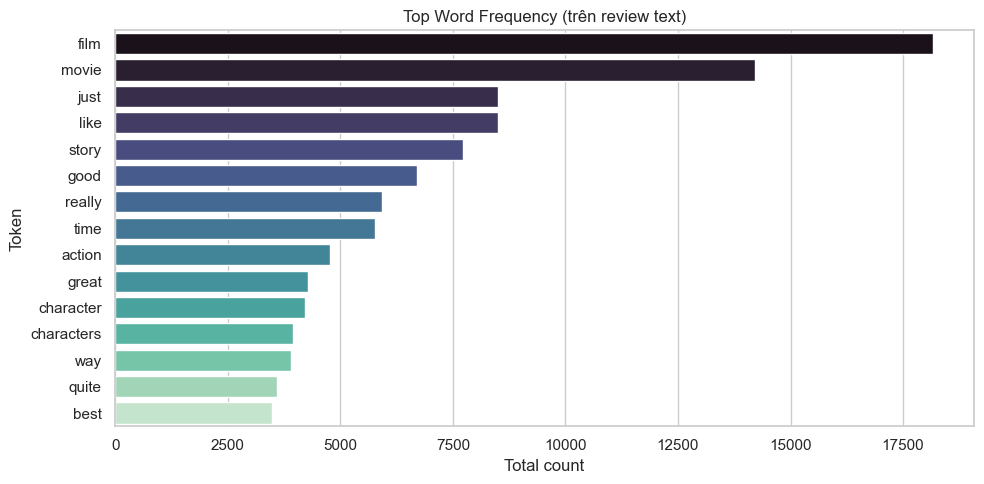

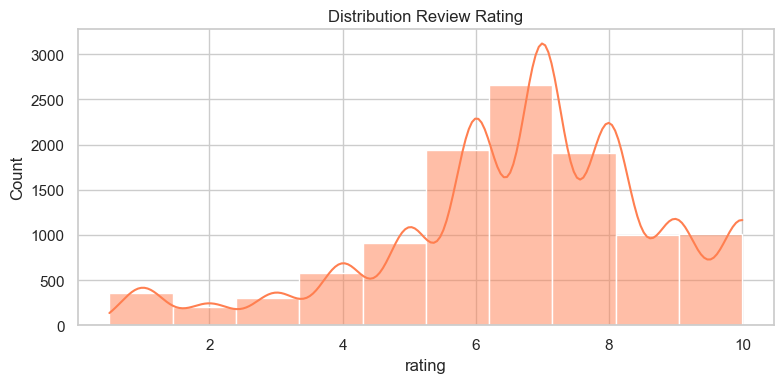

/var/folders/v_/617pz6cj0fgdk8cbm7kv5s9r0000gn/T/ipykernel_80672/2050357551.py:40: MarkupResemblesLocatorWarning: The input passed in on this line looks more like a URL than HTML or XML.

If you meant to use Beautiful Soup to parse the web page found at a certain URL, then something has gone wrong. You should use an Python package like 'requests' to fetch the content behind the URL. Once you have the content as a string, you can feed that string into Beautiful Soup.

However, if you want to parse some data that happens to look like a URL, then nothing has gone wrong: you are using Beautiful Soup correctly, and this warning is spurious and can be filtered. To make this warning go away, run this code before calling the BeautifulSoup constructor:

    from bs4 import MarkupResemblesLocatorWarning
    import warnings

    warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)
    
  text = BeautifulSoup(text, "html.parser").get_text(separator=" ")


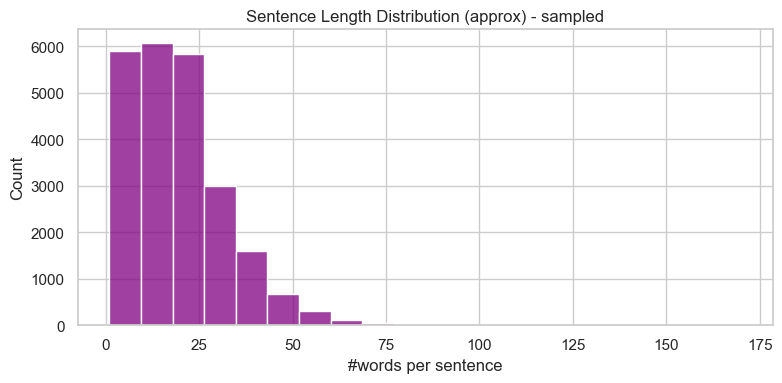

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import unicodedata
from bs4 import BeautifulSoup

sns.set_theme(style="whitegrid")

# --- Text preprocessing ---
_URL_PATTERN = re.compile(r"https?://\S+|www\.\S+", flags=re.IGNORECASE)

# Rough emoji / pictograph range matcher (dependency-free)
_EMOJI_PATTERN = re.compile(
    "["
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F680-\U0001F6FF"  # transport & map symbols
    "\U0001F700-\U0001F77F"
    "\U0001F780-\U0001F7FF"
    "\U0001F800-\U0001F8FF"
    "\U0001F900-\U0001F9FF"
    "\U0001FA00-\U0001FA6F"
    "\U0001FA70-\U0001FAFF"
    "\u2600-\u26FF"          # misc symbols
    "\u2700-\u27BF"          # dingbats
    "]+",
    flags=re.UNICODE,
)

_PUNCT_PATTERN = re.compile(r"[^a-zA-Z0-9\s']+", flags=re.UNICODE)


def clean_text(text: str) -> str:
    """Clean text to satisfy barem: lowercase, remove URL/punct, handle emoji."""
    if not isinstance(text, str) or not text.strip():
        return ""
    text = unicodedata.normalize("NFC", text)
    text = BeautifulSoup(text, "html.parser").get_text(separator=" ")
    text = _URL_PATTERN.sub(" ", text)
    text = _EMOJI_PATTERN.sub(" ", text)
    text = _PUNCT_PATTERN.sub(" ", text)
    text = re.sub(r"\s+", " ", text).strip().lower()
    return text


def tokenize_simple(text: str) -> list[str]:
    """Simple tokenization (no extra dependencies)."""
    text = clean_text(text)
    return [t for t in text.split() if t]


try:
    df_movies = pd.read_csv("cinesense_movies.csv").fillna("")
    df_reviews = pd.read_csv("cinesense_reviews.csv").fillna("")

    # Basic schema validation (để notebook chạy đúng với CSV xuất từ API)
    needed_movies_cols = {"tmdb_id", "title", "overview", "genres"}
    needed_reviews_cols = {"tmdb_id", "content"}

    missing_movies = sorted(needed_movies_cols - set(df_movies.columns))
    missing_reviews = sorted(needed_reviews_cols - set(df_reviews.columns))
    if missing_movies:
        raise ValueError(f"cinesense_movies.csv thiếu cột: {missing_movies}")
    if missing_reviews:
        raise ValueError(f"cinesense_reviews.csv thiếu cột: {missing_reviews}")

    print("1. Làm sạch Overview và Review Content...")
    df_movies["cleaned_overview"] = df_movies["overview"].apply(clean_text)
    df_reviews["cleaned_content"] = df_reviews["content"].apply(clean_text)

    # Export review-level cleaned CSV cho ABSA (để Notebook 03b chỉ load, không xử lý lại)
    absa_cols = [c for c in ["review_id", "tmdb_id", "content", "cleaned_content", "rating", "source"] if c in df_reviews.columns]
    df_absa_clean = df_reviews[absa_cols].copy()
    df_absa_clean = df_absa_clean[df_absa_clean["cleaned_content"].astype(str).str.len() >= 15]
    df_absa_clean.to_csv("absa_clean_reviews.csv", index=False)
    print(f"   -> Đã lưu absa_clean_reviews.csv ({len(df_absa_clean)} dòng)")

    print("2. Gộp reviews theo từng bộ phim (Group by tmdb_id)...")
    grouped_reviews = (
        df_reviews.groupby("tmdb_id")["cleaned_content"]
        .apply(lambda x: " | ".join([t for t in x if isinstance(t, str) and t.strip()]))
        .reset_index()
    )
    grouped_reviews.rename(columns={"cleaned_content": "all_reviews"}, inplace=True)

    print("3. Left Join Movies với Reviews_Grouped...")
    df_merged = pd.merge(df_movies, grouped_reviews, on="tmdb_id", how="left").fillna("")

    # --- Profiles ---
    # movie_profile: title + overview + genres + reviews (useful baseline)
    # review_profile: ONLY review text (matches thesis: recommend based on review text)
    def build_movie_profile(row: pd.Series) -> str:
        sections = [
            f"title: {row.get('title', '')}",
            f"overview: {row.get('cleaned_overview', '')}",
            f"genres: {row.get('genres', '')}",
            f"reviews: {row.get('all_reviews', '')}",
        ]
        return " | ".join(s for s in sections if isinstance(s, str) and s.strip())

    def build_review_profile(row: pd.Series) -> str:
        return str(row.get("all_reviews", "") or "").strip()

    df_merged["movie_profile"] = df_merged.apply(build_movie_profile, axis=1)
    df_merged["review_profile"] = df_merged.apply(build_review_profile, axis=1)

    # Optional: token count for review_profile (for EDA)
    df_merged["review_token_count"] = df_merged["review_profile"].apply(lambda x: len(tokenize_simple(x)))

    # Optional cleanup: drop mostly-missing TMDB vote columns from downstream notebooks
    # (rating theo review vẫn giữ ở df_reviews và absa_clean_reviews.csv).
    for col in ["vote_average", "vote_count"]:
        if col in df_merged.columns:
            df_merged.drop(columns=[col], inplace=True)

    df_merged.to_csv("cleaned_profiles.csv", index=False)

    print("\nĐã tạo xong profiles! Ví dụ Phim 1:")
    if len(df_merged) > 0:
        print("movie_profile:", df_merged["movie_profile"].iloc[0][:400], "...")
        print("review_profile:", df_merged["review_profile"].iloc[0][:400], "...")

    # --- EDA ---
    print("\n--- Bắt đầu EDA ---")
    plt.figure(figsize=(16, 4))

    # Plot 1: Reviews per movie
    plt.subplot(1, 4, 1)
    review_counts = df_reviews["tmdb_id"].value_counts()
    sns.histplot(review_counts, bins=10, color="coral")
    plt.title("Số lượng Review / Phim")

    # Plot 2: Rating distribution (review-level) OR vote_average (movie-level, if available)
    # Lưu ý: trong dataset export hiện tại, `vote_average` thường bị thiếu rất nhiều (đa số null),
    # nên ưu tiên EDA trên `rating` của từng review.
    plt.subplot(1, 4, 2)

    rating_plotted = False
    if "rating" in df_reviews.columns:
        rating_num = pd.to_numeric(df_reviews["rating"], errors="coerce").dropna()
        if len(rating_num) > 0:
            sns.histplot(x=rating_num, bins=10, kde=True, color="skyblue")
            plt.title("Phân phối Rating (review-level)")
            plt.xlabel("rating")
            rating_plotted = True

    if (not rating_plotted) and ("vote_average" in df_movies.columns):
        vote_average = pd.to_numeric(df_movies["vote_average"], errors="coerce")
        non_null = int(vote_average.notna().sum())
        total = int(len(vote_average))
        ratio = (non_null / total) if total else 0.0

        if non_null >= 30 and ratio >= 0.1:
            sns.histplot(
                x=vote_average.dropna(),
                bins=10,
                kde=(non_null > 1),
                color="skyblue",
            )
            plt.title(f"Phân phối Vote Average (movie-level, n={non_null}/{total})")
            plt.xlabel("vote_average")
        else:
            plt.title(f"Vote Average thiếu nhiều (n={non_null}/{total})")
    elif not rating_plotted:
        plt.title("Rating/Vote (missing)")

    # Plot 3: Movie profile length (tokens)
    plt.subplot(1, 4, 3)
    df_merged["movie_profile_token_count"] = df_merged["movie_profile"].apply(lambda x: len(str(x).split()))
    sns.histplot(df_merged["movie_profile_token_count"], bins=10, kde=True, color="purple")
    plt.title("Độ dài Movie Profile (tokens)")

    # Plot 4: Review-only profile length
    plt.subplot(1, 4, 4)
    sns.histplot(df_merged["review_token_count"], bins=10, kde=True, color="seagreen")
    plt.title("Độ dài Review Profile (tokens)")

    plt.tight_layout()
    plt.show()

    # --- Biểu đồ bổ sung (để hiểu sâu hơn / khớp barem) ---
    print("\n--- EDA bổ sung: Genres frequency / Word frequency / Rating / Sentence length ---")

    # 1) Genres frequency (proxy cho "phân bố lớp")
    if "genres" in df_movies.columns:
        genres_series = (
            df_movies["genres"].fillna("")
            .astype(str)
            .str.split(",")
            .apply(lambda xs: [x.strip() for x in xs if x and x.strip()])
            .explode()
        )
        top_genres = genres_series.value_counts().head(15)
        plt.figure(figsize=(10, 5))
        sns.barplot(x=top_genres.values, y=top_genres.index, palette="viridis")
        plt.title("Top Genres (số lượng movies)")
        plt.xlabel("Count")
        plt.ylabel("Genre")
        plt.tight_layout()
        plt.show()

    # 2) Word frequency trên review_profile (top N tokens)
    from sklearn.feature_extraction.text import CountVectorizer

    review_texts = df_merged["review_profile"].fillna("").astype(str)
    # Sampling để tránh chậm với dataset lớn
    sample_n = min(5000, len(review_texts))
    review_sample = review_texts.sample(n=sample_n, random_state=42) if sample_n > 0 else review_texts

    vectorizer = CountVectorizer(stop_words="english", max_features=30, ngram_range=(1, 1))
    X = vectorizer.fit_transform(review_sample.tolist())
    freqs = np.asarray(X.sum(axis=0)).ravel()
    vocab = np.array(vectorizer.get_feature_names_out())
    top_idx = freqs.argsort()[::-1][:15]
    top_words = vocab[top_idx]
    top_counts = freqs[top_idx]

    plt.figure(figsize=(10, 5))
    sns.barplot(x=top_counts, y=top_words, palette="mako")
    plt.title("Top Word Frequency (trên review text)")
    plt.xlabel("Total count")
    plt.ylabel("Token")
    plt.tight_layout()
    plt.show()

    # 3) Distribution của rating theo từng review (nếu rating có)
    if "rating" in df_reviews.columns:
        rating_num = pd.to_numeric(df_reviews["rating"], errors="coerce").dropna()
        if len(rating_num) > 0:
            plt.figure(figsize=(8, 4))
            sns.histplot(x=rating_num, bins=10, kde=True, color="coral")
            plt.title("Distribution Review Rating")
            plt.xlabel("rating")
            plt.ylabel("Count")
            plt.tight_layout()
            plt.show()

    # 4) Độ dài "câu" (approx bằng sentence length) - sampling để nhanh
    # Do clean_text có remove punctuation, ta tách câu dựa trên content raw trước cleaning.
    if "content" in df_reviews.columns:
        df_rev_sample = df_reviews[["content"]].dropna().sample(
            n=min(2000, len(df_reviews)), random_state=42
        )

        sent_lengths: list[int] = []

        def split_sentences(raw: str) -> list[str]:
            raw = str(raw)
            parts = re.split(r"[.!?]+\s*", raw)
            return [p.strip() for p in parts if p and p.strip()]

        for raw in df_rev_sample["content"].tolist():
            for seg in split_sentences(raw):
                cleaned_seg = clean_text(seg)
                if cleaned_seg:
                    sent_lengths.append(len(cleaned_seg.split()))

        if len(sent_lengths) > 0:
            plt.figure(figsize=(8, 4))
            sns.histplot(x=sent_lengths, bins=20, kde=False, color="purple")
            plt.title("Sentence Length Distribution (approx) - sampled")
            plt.xlabel("#words per sentence")
            plt.ylabel("Count")
            plt.tight_layout()
            plt.show()

except FileNotFoundError:
    print("Không tìm thấy file csv. Tạo bằng: (1) chạy Notebook_Report/01_Data_Collection.ipynb (TMDB), hoặc (2) export từ DB: python3 scripts/export_dataset_csv_from_db.py --out-dir Notebook_Report --only-english")
    print("Ví dụ export: từ thư mục gốc repo, cần data/cinesense.db đã seed.")
